# Part 1g: Custom Dropout & Custom Regularization
**Author:** Kalhar Mayurbhai Patel (019140511)

We implement custom dropout variants and a custom regularizer from scratch in both frameworks.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=2000, n_features=20, n_informative=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## TensorFlow: Custom Implementations

### Custom Alpha Dropout (for SELU networks)
Standard dropout breaks SELU's self-normalizing property. Alpha dropout preserves mean and variance.

### Custom Regularizer
We create a regularizer that penalizes weights far from a target value (e.g., encouraging weights near ±0.1).

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


TF Custom Alpha Dropout + Custom Regularizer: Val Acc = 0.9450


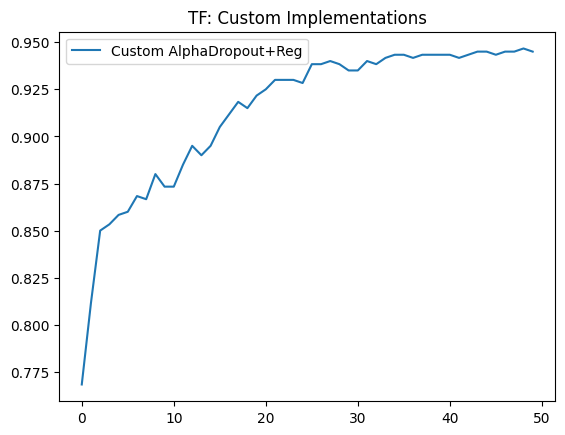

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential, regularizers

# --- Custom Alpha Dropout Layer ---
class AlphaDropout(layers.Layer):
    """Dropout that maintains self-normalizing property for SELU activations."""
    def __init__(self, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate
        self.alpha = -1.7580993408473766

    def call(self, inputs, training=None):
        if not training or self.rate == 0:
            return inputs
        mask = tf.random.uniform(tf.shape(inputs)) >= self.rate
        mask = tf.cast(mask, inputs.dtype)
        # Replace dropped values with alpha * lambda (saturation point)
        sat_val = self.alpha * 1.0507009873554805
        output = tf.where(mask > 0, inputs, sat_val * tf.ones_like(inputs))
        # Affine transform to preserve mean and variance
        a = (1 - self.rate) * (1 + self.rate * sat_val**2)**(-0.5)
        b = -a * sat_val * self.rate
        return a * output + b

# --- Custom Regularizer ---
class TargetWeightRegularizer(tf.keras.regularizers.Regularizer):
    """Penalizes weights that deviate from a target absolute value."""
    def __init__(self, target=0.1, strength=0.01):
        self.target = target
        self.strength = strength

    def __call__(self, weights):
        return self.strength * tf.reduce_mean(tf.square(tf.abs(weights) - self.target))

    def get_config(self):
        return {'target': self.target, 'strength': self.strength}

# Test custom Alpha Dropout with SELU
m_custom = Sequential([
    layers.Dense(64, activation='selu', kernel_initializer='lecun_normal',
                 kernel_regularizer=TargetWeightRegularizer(0.1, 0.01), input_shape=(20,)),
    AlphaDropout(0.2),
    layers.Dense(32, activation='selu', kernel_initializer='lecun_normal'),
    AlphaDropout(0.2),
    layers.Dense(1, activation='sigmoid')
])
m_custom.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
h = m_custom.fit(X_train, y_train, epochs=50, batch_size=32,
                 validation_data=(X_test, y_test), verbose=0)
_, acc = m_custom.evaluate(X_test, y_test, verbose=0)
print(f"TF Custom Alpha Dropout + Custom Regularizer: Val Acc = {acc:.4f}")

plt.plot(h.history['val_accuracy'], label='Custom AlphaDropout+Reg')
plt.title('TF: Custom Implementations'); plt.legend(); plt.show()

## PyTorch: Custom Dropout & Regularizer

PT Custom Dropout + Reg: Final Acc = 0.9433


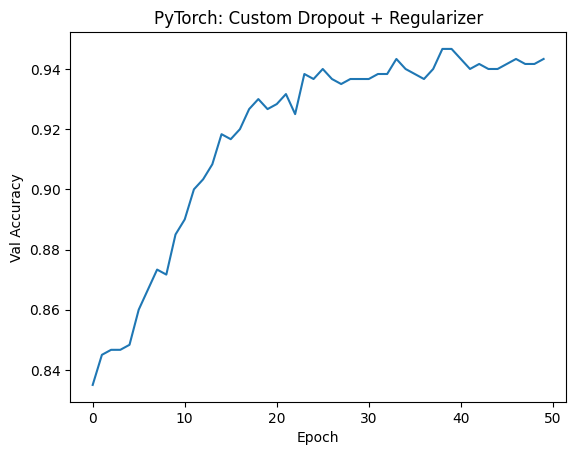

In [3]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class CustomSpatialDropout(nn.Module):
    """Drops entire feature channels instead of individual elements.
    Useful when adjacent features are highly correlated."""
    def __init__(self, rate=0.2):
        super().__init__()
        self.rate = rate

    def forward(self, x):
        if not self.training or self.rate == 0:
            return x
        mask = torch.bernoulli(torch.ones(x.shape[0], x.shape[1]).to(x.device) * (1 - self.rate))
        return x * mask / (1 - self.rate)  # Scale to maintain expected value

class TargetWeightPenalty:
    """Custom regularization: penalize weights far from a target absolute value."""
    def __init__(self, target=0.1, strength=0.01):
        self.target = target
        self.strength = strength

    def __call__(self, model):
        penalty = 0
        for p in model.parameters():
            if p.dim() >= 2:  # Only weight matrices, not biases
                penalty += torch.mean((p.abs() - self.target) ** 2)
        return self.strength * penalty

class CustomNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(20, 64)
        self.drop1 = CustomSpatialDropout(0.2)
        self.fc2 = nn.Linear(64, 32)
        self.drop2 = CustomSpatialDropout(0.2)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.drop1(torch.selu(self.fc1(x)))
        x = self.drop2(torch.selu(self.fc2(x)))
        return torch.sigmoid(self.fc3(x))

dl = DataLoader(TensorDataset(torch.FloatTensor(X_train).to(device),
    torch.FloatTensor(y_train).unsqueeze(1).to(device)), batch_size=32, shuffle=True)
X_te = torch.FloatTensor(X_test).to(device)
y_te = torch.FloatTensor(y_test).unsqueeze(1).to(device)

torch.manual_seed(42)
model = CustomNet().to(device)
opt = torch.optim.Adam(model.parameters())
crit = nn.BCELoss()
reg = TargetWeightPenalty(target=0.1, strength=0.01)

accs = []
for ep in range(50):
    model.train()
    for xb, yb in dl:
        loss = crit(model(xb), yb) + reg(model)
        opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        accs.append(((model(X_te)>0.5).float()==y_te).float().mean().item())

print(f"PT Custom Dropout + Reg: Final Acc = {accs[-1]:.4f}")
plt.plot(accs); plt.title('PyTorch: Custom Dropout + Regularizer')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.show()

## Highlights
- **Alpha Dropout** preserves the self-normalizing property of SELU — standard dropout breaks it
- **Spatial/Channel Dropout** drops entire feature maps — useful for correlated features
- **Custom Regularizer** can encode domain-specific priors about expected weight distributions
- Both frameworks allow easy extension of built-in components